In [1]:
import matplotlib.pyplot as plt

import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

Downloading bucket files: 54198050 / 54198050 complete

Downloading bytes: 54198050 / 54198050 complete

Downloading bucket files: 60301820 / 60301820 complete

Downloading bytes: 60301820 / 60301820 complete

In [2]:
merged_path = "scarf_datasets/kang_dataset_merging.zarr"
scarf.AssayMerge(
    zarr_path=merged_path,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()

ds = scarf.DataStore(merged_path, nthreads=4)

Writing merged assay: 16 / 16 complete

Computing RNA initialization statistics: 7 / 7 complete

In [3]:
ds.cells.to_pandas_dataframe(
    ["ids", "sample_id", "orig_cluster_labels", "I"]
).head()

,ids,sample_id,orig_cluster_labels,I
0,ctrl__TGTTAAGACACTGA-1,ctrl,nan,False
1,ctrl__TCACCCGAGCTATG-1,ctrl,nan,False
2,ctrl__TCACCCGAACCACA-1,ctrl,CD4 Memory T,True
3,ctrl__TGTAGTCTACCAGT-1,ctrl,CD8 T,True
4,ctrl__TATCAGCTAGTAGA-1,ctrl,B,True


In [4]:
ds.cells.to_pandas_dataframe(
    ["sample_id"],
    key="I",
)["sample_id"].value_counts()

sample_id
stim    10111
ctrl     8487
Name: count, dtype: int64

In [5]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)
ds.run_normalization(feat_key="hvgs")
ds.run_pca(dims=25)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)

Computing RNA feature statistics: 35 / 35 complete

Writing data: 2 / 2 complete

Fitting PCA: 2 / 2 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

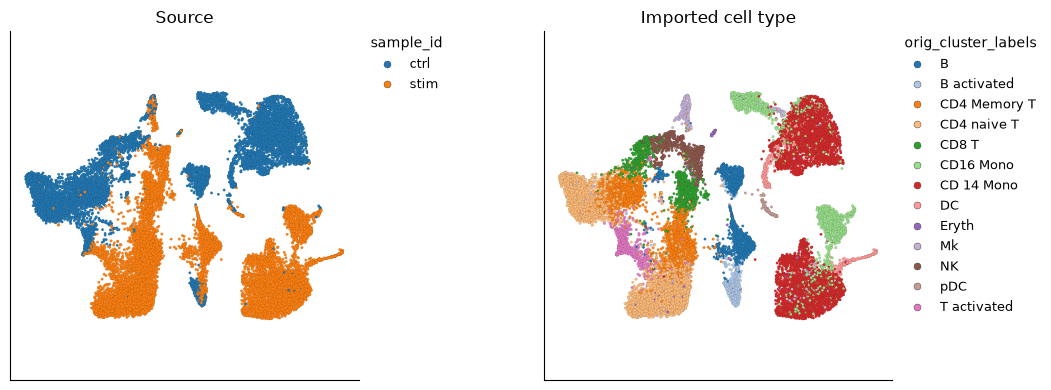

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_panels = (
    ("Source", "sample_id"),
    ("Imported cell type", "orig_cluster_labels"),
)
for axis, (title, color_by) in zip(axes, comparison_panels, strict=True):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=color_by,
        legend_loc="right",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()